No código, cada "Indivíduo" da nossa população será um objeto (ou um dicionário) que carrega duas informações genéticas essenciais:

    Camada 1: O Gene de Rota (Ordem dos Estados)

        É um array com 27 posições contendo a sigla dos estados misturadas aleatoriamente.

        Exemplo: ['RN', 'CE', 'PI', 'MA', ..., 'SP', 'RJ']

        Regra de Ouro: O 'RN' (ou especificamente o aeroporto de Natal, SBSG) deve idealmente ser fixado como o início e o fim da rota na hora de calcular o fitness, mas a permutação dos outros 26 estados é o que a IA vai otimizar.

    Camada 2: O Gene de Seleção (Qual Aeroporto?)

        É um array paralelo, também com 27 posições, contendo números inteiros. Esse número representa o índice do aeroporto escolhido dentro daquele estado.

        Exemplo: Se a Rota passa por 'SP', e sabemos que SP tem 3 aeroportos na nossa lista (0=Guarulhos, 1=Viracopos, 2=Congonhas), o gene de seleção para a posição de SP terá o valor 0, 1 ou 2. Para estados com apenas 1 aeroporto (como o RN), o gene será sempre 0.

O que o nosso algoritmo vai precisar fazer?
    Com essa estrutura dupla, teremos que criar regras especiais para os operadores evolutivos que você viu na Aula 1 (Genéticos):

        Mutação: Podemos ter dois tipos de mutação. Uma que troca a ordem de dois estados na rota, e outra que "vira a chave" de um aeroporto (ex: muda de Congonhas para Guarulhos) para ver se o trajeto total encurta.

        Crossover: Teremos que usar cruzamentos baseados em permutação (como o PMX ou OX) para a camada de Rota (para garantir que nenhum estado seja duplicado ou esquecido), e um cruzamento simples (troca de metades) para a camada de Seleção.

        Aptidão (Fitness): A função que lê a Rota, pega os aeroportos selecionados, e soma as distâncias consultando instantaneamente o seu matriz_distancias.csv. Quanto menor a distância total, maior a aptidão.

In [2]:
import pandas as pd

# lendo a matriz de distancias
matriz_distancias = pd.read_csv("matriz_distancias.csv", index_col=0)

Dicionário pra mapear os identificadores textuais dos aeroportos com seus respectivos estados:

In [3]:
# mapa de estados:
df = pd.read_csv("dataset_final_clean.csv")
# agrupando por estado e criando uma lista com os identificadores dos aeroportos
mapa_estados = df.groupby('iso_region')['ident'].apply(list).to_dict()
display(mapa_estados)

{'BR-AC': ['SBRB'],
 'BR-AL': ['SBMO'],
 'BR-AM': ['SBEG'],
 'BR-AP': ['SBMQ'],
 'BR-BA': ['SBPS', 'SBSV'],
 'BR-CE': ['SBFZ'],
 'BR-DF': ['SBBR'],
 'BR-ES': ['SBVT'],
 'BR-GO': ['SBGO'],
 'BR-MA': ['SBSL'],
 'BR-MG': ['SBCF'],
 'BR-MS': ['SBCG'],
 'BR-MT': ['SBCY'],
 'BR-PA': ['SBBE'],
 'BR-PB': ['SBJP'],
 'BR-PE': ['SBRF'],
 'BR-PI': ['SBTE'],
 'BR-PR': ['SBCT', 'SBFI'],
 'BR-RJ': ['SBGL', 'SBRJ'],
 'BR-RN': ['SBSG'],
 'BR-RO': ['SBPV'],
 'BR-RR': ['SBBV'],
 'BR-RS': ['SBPA'],
 'BR-SC': ['SBFL', 'SBNF'],
 'BR-SE': ['SBAR'],
 'BR-SP': ['SBGR', 'SBKP', 'SBSP'],
 'BR-TO': ['SBPJ']}

Definindo a anatomia de cada individuo, em outras palavras, o cromossomo do algoritmo genetico:

In [4]:
import random

# anatomia do individuo, o cromossomo:
class Individuo:
    def __init__(self, lista_estados, mapa_estados):
        """
        Gera um indivíduo aleatório para a população inicial.
        """
        # --- CAMADA 1: O Gene de Rota (Ordem dos Estados) ---
        # faz uma cópia da lista de estados para não alterar a original
        # tira o ponto fixo (RN) da lista temporariamente, pois é o inicio fixo
        estados_para_embaralhar = lista_estados.copy()
        estados_para_embaralhar.remove('BR-RN')
        
        # embaralha os estados para criar uma rota aleatória
        # embaralhando apenas os 26 estados restantes
        random.shuffle(estados_para_embaralhar)

        # montando a camada 1: RN travado na posição [0], seguido do resto
        self.rota_estados = ['BR-RN'] + estados_para_embaralhar
        
        # --- CAMADA 2: O Gene de Seleção (Qual Aeroporto? dentro de cada estado, nos estados que só tem um, o indice sempre será o mesmo, nos que tem mais de um, o indice terá 3 distintos) ---
        self.selecao_aeroportos = []
        
        # para cada estado na nossa rota embaralhada, sorteamos um aeroporto
        for estado in self.rota_estados:
            # ve quantos aeroportos esse estado tem
            opcoes_disponiveis = len(mapa_estados[estado])
            
            # sorteia um índice (se tiver só 1, vai sortear 0 sempre)
            indice_escolhido = random.randint(0, opcoes_disponiveis - 1)
            self.selecao_aeroportos.append(indice_escolhido)
            
        # o fitness nasce zerado e será calculado pelo ambiente(funcao de aptidão) depois
        self.fitness = 0.0
        
    def __repr__(self):
        """Função apenas para imprimir o indivíduo bonitinho na tela"""
        return f"<Individuo | Fitness: {self.fitness:.2f} | Rota: {self.rota_estados[:26]}>"

Definindo a função de aptidão/fitness do algoritmo genético:

In [5]:
# funcao de aptidão / ambiente:
def avaliar_aptidao(individuo, matriz_distancias, mapa_estados):
    """
    Decodifica o cromossomo do indivíduo, calcula a distância total da rota
    e atribui a nota de aptidão (fitness).
    """
    
    # decodificação ( "genótipo" para "fenótipo" ), por exemplo, 'estado = BR-SP, índice = 1' para 'SBKP'
    rota_aeroportos = []
    
    for i in range(len(individuo.rota_estados)):
        estado = individuo.rota_estados[i]
        indice_aeroporto = individuo.selecao_aeroportos[i]
        
        # pega a sigla exata do aeroporto usando o dicionário mapa_estados
        sigla_aeroporto = mapa_estados[estado][indice_aeroporto]
        rota_aeroportos.append(sigla_aeroporto)
        
    # calculo da distancia (consulta na matriz) 
    distancia_total = 0.0
    
    # percorre a rota do índice 0 até o penúltimo (25)
    for i in range(len(rota_aeroportos) - 1):
        origem = rota_aeroportos[i]
        destino = rota_aeroportos[i+1]
        
        # busca a distância no dataframe pandas 
        distancia_total += matriz_distancias.loc[origem, destino]
        
    
    # soma a viagem do último estado de volta para o primeiro (que é o RN)
    # esse passo garante que no final a viagem volte ao RN, como foi convencionado na idealização do projeto
    ultimo = rota_aeroportos[-1]
    primeiro = rota_aeroportos[0]
    distancia_total += matriz_distancias.loc[ultimo, primeiro]
    
    # atribuir o fitness
    # o algoritmo genético clássico sempre busca maximizar o fitness
    # mas o nosso projeto quer MINIMIZAR a distância percorrida na viagem
    # o truque matemático: inverter a distância (1 / distância_total)
    # assim, uma distância menor gera um fitness maior
    
    individuo.fitness = 100000.0 / distancia_total # multiplicamos por 100.000 só pro número não ficar com muitos zeros (ex: 0.00002)
    
    # guardando a distância real dentro do indivíduo também 
    # pois fica mais fácil pra ler os resultados depois
    individuo.distancia_real = distancia_total
    
    return individuo.fitness

Gerando a população inicial:

In [6]:
def gerar_populacao_inicial(tamanho_populacao, lista_estados, mapa_estados, matriz_distancias):
    """
    Cria uma lista de indivíduos aleatórios e já calcula a aptidão (fitness) de cada um.
    """
    populacao = []
    
    for _ in range(tamanho_populacao):
        # cria um novo viajante com DNA aleatório
        novo_viajante = Individuo(lista_estados, mapa_estados)
        
        # o ambiente(funcao de aptidao) avalia a rota dele e anota o fitness e a distância que ele percorreu
        avaliar_aptidao(novo_viajante, matriz_distancias, mapa_estados)
        
        # colocando o viajante na população
        populacao.append(novo_viajante)
        
    return populacao

Teste inicial:

In [7]:
# pegando a lista de estados direto das chaves do dicionário
lista_de_estados = list(mapa_estados.keys())

# decidindo o tamanho da população 
tamanho_pop = 100

# criação da geração de teste
populacao_teste = gerar_populacao_inicial(tamanho_pop, lista_de_estados, mapa_estados, matriz_distancias)

# analise dos resultados
# ordenando a população para ver quem é o melhor (maior fitness primeiro)
# O lambda ensina o Python a olhar dentro da 'mochila' do indivíduo para ordenar
populacao_ordenada = sorted(populacao_teste, key=lambda ind: ind.fitness, reverse=True)

melhor_aleatorio = populacao_ordenada[0]
pior_aleatorio = populacao_ordenada[-1]

print("--- GERAÇÃO 0 (TOTALMENTE ALEATÓRIA) ---")
print(f"Melhor distância encontrada por sorte: {melhor_aleatorio.distancia_real:.2f} km")
print(f"Pior distância encontrada: {pior_aleatorio.distancia_real:.2f} km")
print(f"\nRota do Melhor: {melhor_aleatorio.rota_estados[:26]}")

--- GERAÇÃO 0 (TOTALMENTE ALEATÓRIA) ---
Melhor distância encontrada por sorte: 36522.94 km
Pior distância encontrada: 57001.44 km

Rota do Melhor: ['BR-RN', 'BR-AL', 'BR-PE', 'BR-PB', 'BR-CE', 'BR-RJ', 'BR-RO', 'BR-SE', 'BR-BA', 'BR-SC', 'BR-TO', 'BR-GO', 'BR-SP', 'BR-MS', 'BR-DF', 'BR-ES', 'BR-PI', 'BR-MA', 'BR-MG', 'BR-AM', 'BR-RR', 'BR-PR', 'BR-RS', 'BR-AC', 'BR-MT', 'BR-AP']


A classe e as funções criadas até aqui estão funcionando perfeitamente

Definindo a função de seleção, o método escolhido foi o do Torneio:

In [8]:
def selecao_torneio(populacao, tamanho_torneio=3):
    """
    Sorteia 'tamanho_torneio'(a escolha inicial foi 3) indivíduos aleatórios da população.
    O vencedor do torneio (o escolhido para cruzar) é o que tem o maior fitness.
    """
    
    # sorteia 3 indivíduos aleatórios da população atual
    competidores = random.sample(populacao, tamanho_torneio)
    
    # compara a aptidao deles e retorna o que tem o maior fitness
    vencedor = max(competidores, key=lambda ind: ind.fitness)
    
    return vencedor

Teste de seleção:

In [9]:
print(selecao_torneio(populacao_teste))

<Individuo | Fitness: 2.22 | Rota: ['BR-RN', 'BR-DF', 'BR-RR', 'BR-PB', 'BR-SE', 'BR-PE', 'BR-TO', 'BR-AP', 'BR-CE', 'BR-PI', 'BR-BA', 'BR-AC', 'BR-AL', 'BR-PA', 'BR-MA', 'BR-PR', 'BR-ES', 'BR-SC', 'BR-AM', 'BR-SP', 'BR-RO', 'BR-MT', 'BR-GO', 'BR-MG', 'BR-RS', 'BR-RJ']>


Definir a função de crossover
    
    no gene de Seleção de Aeroportos, podemos cortar no meio e misturar os índices tranquilamente. Mas no gene de Rota de Estados, não podemos fazer um corte simples. Se misturarmos metade da rota do Pai 1 com metade do Pai 2, poderíamos criar um filho com dois estados de São Paulo e nenhum do Rio de Janeiro, o que geraria uma rota inválida.
        
    a escolha do crossover pro gene dae Rota foi o OX (Order Crossover): copia o miolo de um pai e preenche o restante com os estados que faltam, seguindo estritamente a ordem em que aparecem no outro pai.

In [10]:
def crossover_ox(pai1, pai2, lista_estados, mapa_estados):
    """
    Aplica o Order Crossover (OX) em dois pais para gerar dois filhos.
    Preserva o RN no índice 0 e faz o cruzamento apenas nos 26 estados restantes.
    """
    
    # criando os filhos vazios (os genes aleatórios vão ser sobrescritos)
    filho1 = Individuo(lista_estados, mapa_estados)
    filho2 = Individuo(lista_estados, mapa_estados)
    
    # isolando a parte mutável (do índice 1 até o final) (pra proteger o começo no RN como convencionado, estando protegido no indice 0)
    rota_pai1 = pai1.rota_estados[1:]
    sel_pai1  = pai1.selecao_aeroportos[1:]
    
    rota_pai2 = pai2.rota_estados[1:]
    sel_pai2  = pai2.selecao_aeroportos[1:]
    
    # "zipando" as camadas para que a escolha do aeroporto "viaje" junto com o estado
    genes_pai1 = list(zip(rota_pai1, sel_pai1))
    genes_pai2 = list(zip(rota_pai2, sel_pai2))
    
    tamanho = len(genes_pai1) # será 26
    
    # sorteia dois pontos de corte diferentes
    corte1, corte2 = sorted(random.sample(range(tamanho), 2))
    
    # --- FUNÇÃO INTERNA QUE FAZ A MÁGICA DO OX ---
    def gerar_dna_filho(pai_principal, pai_secundario):
        dna_filho = [None] * tamanho
        
        # copia o miolo do primeiro pai 
        dna_filho[corte1:corte2] = pai_principal[corte1:corte2]
        
        # cria um set/conjunto com os estados que já estão no filho para consulta rápida
        estados_no_filho = set([gene[0] for gene in dna_filho if gene is not None])
        
        # preenche o resto circularmente usando o segundo pai
        idx_insercao = corte2
        for i in range(tamanho):
            idx_busca = (corte2 + i) % tamanho # o módulo (%) faz o índice dar a volta pro 0
            gene_sec = pai_secundario[idx_busca]
            
            if gene_sec[0] not in estados_no_filho:
                if idx_insercao >= tamanho:
                    idx_insercao = 0 # dá a volta no filho também
                dna_filho[idx_insercao] = gene_sec
                idx_insercao += 1
                
        return dna_filho
    # ---------------------------------------------
    
    # gerando o DNA dos dois filhos invertendo os pais
    genes_filho1 = gerar_dna_filho(genes_pai1, genes_pai2)
    genes_filho2 = gerar_dna_filho(genes_pai2, genes_pai1)
    
    # desempacotando (desfazendo o zip) e reconstruindo os indivíduos (Travando o RN na posição 0)
    # obs: o aeroporto do RN é sempre o índice 0 (SBSG) no mapa_estados
    filho1.rota_estados = ['BR-RN'] + [g[0] for g in genes_filho1]
    filho1.selecao_aeroportos = [0] + [g[1] for g in genes_filho1]
    
    filho2.rota_estados = ['BR-RN'] + [g[0] for g in genes_filho2]
    filho2.selecao_aeroportos = [0] + [g[1] for g in genes_filho2]
    
    return filho1, filho2

Definindo a mutação:

    Como temos um Cromossoma de Dupla Camada, a nossa função de mutação terá de fazer duas coisas distintas:

        Mutação de Rota (Swap): Trocar a ordem de dois estados (do índice 1 ao 26).

        Mutação de Aeroporto (Flip): Escolher um estado que tenha mais do que um aeroporto e forçar a troca do aeroporto selecionado.

In [11]:
def mutacao(individuo, taxa_mutacao, mapa_estados):
    """
    Aplica mutações na rota e na seleção de aeroportos do indivíduo.
    O índice 0 (RN) é intocável.
    """
    
    tamanho_rota = len(individuo.rota_estados)
    
    # --- MUTAÇÃO DE ROTA (Swap) ---
    # sorteia um número de 0.0 a 1.0. Se for menor que a taxa, ocorre a mutação.
    if random.random() < taxa_mutacao:
        # escolhe dois índices aleatórios diferentes (do 1 ao 26) (sem o 0 pra proteger o RN no inicio)
        idx1, idx2 = random.sample(range(1, tamanho_rota), 2)
        
        # troca os estados de lugar
        individuo.rota_estados[idx1], individuo.rota_estados[idx2] = \
            individuo.rota_estados[idx2], individuo.rota_estados[idx1]
            
        # IMPORTANTE: troca os aeroportos correspondentes para que viajem juntos!
        individuo.selecao_aeroportos[idx1], individuo.selecao_aeroportos[idx2] = \
            individuo.selecao_aeroportos[idx2], individuo.selecao_aeroportos[idx1]
            
            
    # --- MUTAÇÃO DE AEROPORTO (Flip) ---
    if random.random() < taxa_mutacao:
        # escolhe um índice aleatório na rota (do 1 ao 26)
        idx_mut = random.randint(1, tamanho_rota - 1)
        estado_alvo = individuo.rota_estados[idx_mut]
        
        # verifica quantos aeroportos existem neste estado
        opcoes = len(mapa_estados[estado_alvo])
        
        # só faz sentido tentar mutar se o estado tiver 2 ou mais aeroportos (ex: SP, RJ, PR)
        if opcoes > 1:
            aeroporto_atual = individuo.selecao_aeroportos[idx_mut]
            novo_aeroporto = random.randint(0, opcoes - 1)
            
            # garante que o aeroporto sorteado seja efetivamente diferente do atual
            while novo_aeroporto == aeroporto_atual:
                novo_aeroporto = random.randint(0, opcoes - 1)
                
            # aplica a mutação
            individuo.selecao_aeroportos[idx_mut] = novo_aeroporto

Definir o "motor" das gerações, a parte que irá rodar o algoritmo como um todo:

    foi implementado um Elitismo: "Pegue o melhor indivíduo da geração atual e copie ele intacto para a próxima geração". Assim, a IA só evolui para frente, nunca "desaprende".

In [12]:
def executar_algoritmo_genetico(tamanho_pop, geracoes, taxa_mutacao, lista_estados, mapa_estados, matriz_distancias):
    """
    O laço principal que controla o tempo e a evolução da população.
    Retorna o melhor indivíduo encontrado e o histórico de distâncias para gerarmos um gráfico.
    """
    # nascimento da geração inicial
    populacao = gerar_populacao_inicial(tamanho_pop, lista_estados, mapa_estados, matriz_distancias)
    
    # variáveis para guardar o recordista/vencedor e o histórico de distancias
    melhor_individuo_global = max(populacao, key=lambda ind: ind.fitness)
    historico_distancias = [melhor_individuo_global.distancia_real]
    
    print("--- INICIANDO A EVOLUÇÃO ---")
    print(f"Geração Inicial   | Melhor Distância: {melhor_individuo_global.distancia_real:.2f} km")
    
    # a "máquina do tempo" ( o laço de gerações )
    for geracao in range(1, geracoes + 1):
        nova_populacao = []
        
        # --- ELITISMO ---
        # encontra o melhor da geração atual e clona ele para a nova geração
        melhor_da_geracao = max(populacao, key=lambda ind: ind.fitness)
        nova_populacao.append(melhor_da_geracao)
        
        # preenchendo o resto da nova população (de 2 em 2 filhos)
        while len(nova_populacao) < tamanho_pop:
            # Seleção (Torneio)
            pai1 = selecao_torneio(populacao)
            pai2 = selecao_torneio(populacao)
            
            # Reprodução (Crossover OX)
            filho1, filho2 = crossover_ox(pai1, pai2, lista_estados, mapa_estados)
            
            # Mutação ( pra evitar minimos locais)
            mutacao(filho1, taxa_mutacao, mapa_estados)
            mutacao(filho2, taxa_mutacao, mapa_estados)
            
            # Função de Aptidão (dando um fitness aos filhos)
            avaliar_aptidao(filho1, matriz_distancias, mapa_estados)
            avaliar_aptidao(filho2, matriz_distancias, mapa_estados)
            
            # ss filhos entram na nova sociedade
            nova_populacao.append(filho1)
            # trava de segurança: se a população já encheu, não adiciona o segundo filho
            if len(nova_populacao) < tamanho_pop:
                nova_populacao.append(filho2)
                
        # a velha geração morre, a nova assume
        populacao = nova_populacao
        
        # atualiza o recorde global se a nova geração produziu alguém melhor
        melhor_da_geracao = max(populacao, key=lambda ind: ind.fitness)
        if melhor_da_geracao.fitness > melhor_individuo_global.fitness:
            melhor_individuo_global = melhor_da_geracao
            
        # salva o recorde atual no histórico para desenharmos o gráfico depois
        historico_distancias.append(melhor_individuo_global.distancia_real)
        
        # imprime o progresso a cada 50 gerações para não inundar a tela
        if geracao % 50 == 0:
            print(f"Geração {geracao:<3} | Melhor Distância: {melhor_individuo_global.distancia_real:.2f} km")
            
    print("--- EVOLUÇÃO CONCLUÍDA ---")
    return melhor_individuo_global, historico_distancias

Agora é a execução e resolução do nosso problema:

In [13]:
# --- CONFIGURAÇÕES DO ALGORITMO ---
TAMANHO_DA_POPULACAO = 150   # quantidade de viajantes por geração
NUMERO_DE_GERACOES = 500     # quantas vezes o ciclo vai rodar
TAXA_DE_MUTACAO = 0.05       # 5% de chance de ocorrer uma mutação

# --- EXECUTANDO ---
# usando variaveis que foram definidas agora e anteriormente
melhor_viajante, historico = executar_algoritmo_genetico(
    TAMANHO_DA_POPULACAO, 
    NUMERO_DE_GERACOES, 
    TAXA_DE_MUTACAO, 
    lista_de_estados, 
    mapa_estados, 
    matriz_distancias  
)

print("\n--- RESULTADO FINAL ---")
print(f"Distância Otimizada: {melhor_viajante.distancia_real:.2f} km")

# para ver o fenótipo ( quais aeroportos a IA escolheu )
rota_final_aeroportos = [mapa_estados[est][idx] for est, idx in zip(melhor_viajante.rota_estados, melhor_viajante.selecao_aeroportos)]
# adiciona a volta pro RN no print final para ficar didático
rota_final_aeroportos.append('SBSG') 
print(f"Rota Completa de Voo:\n{' -> '.join(rota_final_aeroportos)}")

--- INICIANDO A EVOLUÇÃO ---
Geração Inicial   | Melhor Distância: 37352.61 km
Geração 50  | Melhor Distância: 18864.11 km
Geração 100 | Melhor Distância: 17617.79 km
Geração 150 | Melhor Distância: 17617.79 km
Geração 200 | Melhor Distância: 17617.79 km
Geração 250 | Melhor Distância: 17617.79 km
Geração 300 | Melhor Distância: 17617.79 km
Geração 350 | Melhor Distância: 17617.79 km
Geração 400 | Melhor Distância: 17617.79 km
Geração 450 | Melhor Distância: 17617.79 km
Geração 500 | Melhor Distância: 17617.79 km
--- EVOLUÇÃO CONCLUÍDA ---

--- RESULTADO FINAL ---
Distância Otimizada: 17617.79 km
Rota Completa de Voo:
SBSG -> SBVT -> SBGL -> SBGR -> SBCF -> SBGO -> SBBR -> SBPJ -> SBAR -> SBMO -> SBRF -> SBFZ -> SBTE -> SBSL -> SBBE -> SBMQ -> SBBV -> SBEG -> SBPV -> SBRB -> SBCY -> SBCG -> SBFI -> SBPA -> SBNF -> SBSV -> SBJP -> SBSG


In [14]:
import numpy as np
import time

# --- CONFIGURAÇÕES DA BATERIA ---
NUM_EXECUCOES = 30
TAMANHO_DA_POPULACAO = 250
NUMERO_DE_GERACOES = 1100
TAXA_DE_MUTACAO = 0.1

print(f"Iniciando bateria de {NUM_EXECUCOES} testes...")

# Variáveis para guardar estatísticas
todas_distancias = []
todos_historicos = []
melhor_individuo_global = None
melhor_distancia_global = float('inf')

tempo_inicio = time.time()

for i in range(NUM_EXECUCOES):
    # Roda o algoritmo genético silenciosamente (sem aqueles prints internos se você os tirou, 
    # ou simplesmente ignore a poluição visual por enquanto)
    melhor_viajante, historico = executar_algoritmo_genetico(
        TAMANHO_DA_POPULACAO, 
        NUMERO_DE_GERACOES, 
        TAXA_DE_MUTACAO, 
        lista_de_estados, 
        mapa_estados, 
        matriz_distancias
    )
    
    distancia_final = melhor_viajante.distancia_real
    todas_distancias.append(distancia_final)
    todos_historicos.append(historico)
    
    # Atualiza o recordista absoluto de todas as 30 rodadas
    if distancia_final < melhor_distancia_global:
        melhor_distancia_global = distancia_final
        melhor_individuo_global = melhor_viajante
        historico_do_melhor = historico
        
    print(f"Execução {i+1}/{NUM_EXECUCOES} concluída. Distância: {distancia_final:.2f} km")

tempo_fim = time.time()

# --- ESTATÍSTICAS FINAIS ---
print("\n" + "="*40)
print("🎯 RESULTADOS DA BATERIA DE TESTES 🎯")
print("="*40)
print(f"Tempo total de processamento: {(tempo_fim - tempo_inicio):.2f} segundos")
print(f"Pior Rota Encontrada:  {np.max(todas_distancias):.2f} km")
print(f"Distância Média:       {np.mean(todas_distancias):.2f} km")
print(f"Desvio Padrão:         {np.std(todas_distancias):.2f} km")
print(f"🏆 MELHOR ROTA GLOBAL:  {melhor_distancia_global:.2f} km")

# Imprime a rota dos campeões
rota_final_aeroportos = [mapa_estados[est][idx] for est, idx in zip(melhor_individuo_global.rota_estados, melhor_individuo_global.selecao_aeroportos)]
rota_final_aeroportos.append('SBSG') # Volta para Natal
print(f"\nA Rota Perfeita:\n{' -> '.join(rota_final_aeroportos)}")

Iniciando bateria de 30 testes...
--- INICIANDO A EVOLUÇÃO ---
Geração Inicial   | Melhor Distância: 37413.76 km
Geração 50  | Melhor Distância: 22279.80 km
Geração 100 | Melhor Distância: 20219.83 km
Geração 150 | Melhor Distância: 14154.90 km
Geração 200 | Melhor Distância: 14154.90 km
Geração 250 | Melhor Distância: 14154.90 km
Geração 300 | Melhor Distância: 14154.90 km
Geração 350 | Melhor Distância: 14154.90 km
Geração 400 | Melhor Distância: 14154.90 km
Geração 450 | Melhor Distância: 14154.90 km
Geração 500 | Melhor Distância: 14154.90 km
Geração 550 | Melhor Distância: 14154.90 km
Geração 600 | Melhor Distância: 14154.90 km
Geração 650 | Melhor Distância: 14154.90 km
Geração 700 | Melhor Distância: 14154.90 km
Geração 750 | Melhor Distância: 14154.90 km
Geração 800 | Melhor Distância: 14154.90 km
Geração 850 | Melhor Distância: 14154.90 km
Geração 900 | Melhor Distância: 14154.90 km
Geração 950 | Melhor Distância: 14154.90 km
Geração 1000 | Melhor Distância: 14154.90 km
Geraçã

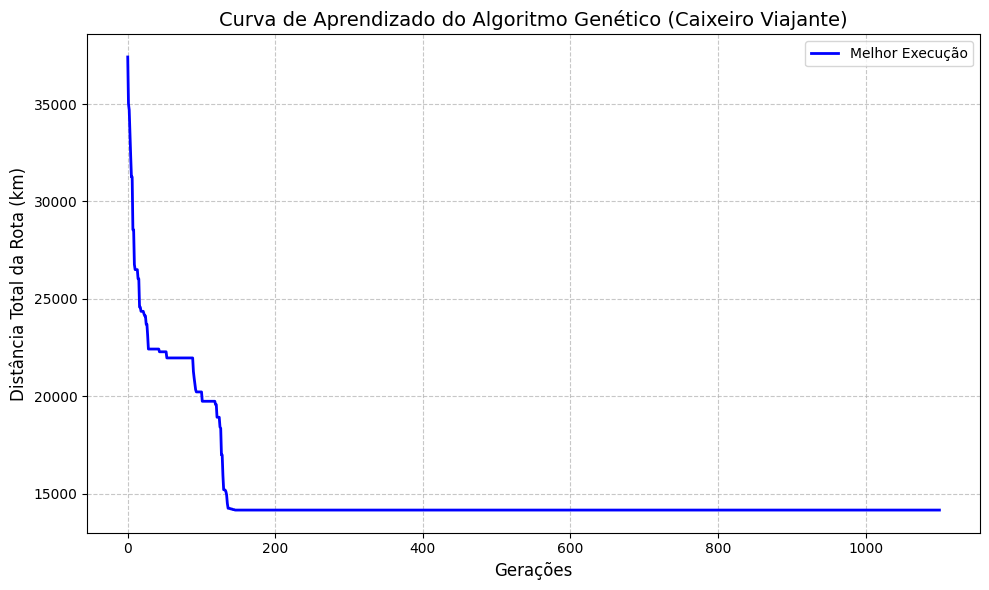

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plota a linha da melhor execução de todas
plt.plot(historico_do_melhor, color='blue', linewidth=2, label='Melhor Execução')

plt.title('Curva de Aprendizado do Algoritmo Genético (Caixeiro Viajante)', fontsize=14)
plt.xlabel('Gerações', fontsize=12)
plt.ylabel('Distância Total da Rota (km)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# Mostra o gráfico na tela
plt.show()